# Notebook 03 — Exploratory Data Analysis (EDA)

EDA ưu tiên PM2.5 **quan sát gốc**, không nội suy. Biểu đồ chuỗi thời gian giữ nguyên các khoảng thiếu để tránh tạo cảm giác dữ liệu liên tục khi máy đo không có quan sát.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

# Tìm gốc repo có chứa file dữ liệu gốc để đường dẫn chạy được trên Colab.
DATA_RELATIVE = Path("PRSA_data_2010.1.1-2014.12.31.csv")
repo_candidates = [
    Path.cwd(),
    Path("/content/PPNCKH_5Bros"),
    Path("/content"),
]
PROJECT_ROOT = next(
    (root.resolve() for root in repo_candidates if (root / DATA_RELATIVE).exists()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Không tìm thấy dữ liệu gốc: {DATA_RELATIVE}. "
        "Kiểm tra repo đã được clone vào /content/PPNCKH_5Bros và file raw nằm đúng vị trí."
    )

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE
OUTPUT_ROOT = PROJECT_ROOT / "PPNCKH_5Bros/notebooks/phuong_nb/output"
DATA_OUT = OUTPUT_ROOT / "data"
FIG_OUT = OUTPUT_ROOT / "figures"
TABLE_OUT = OUTPUT_ROOT / "tables"
for folder in (DATA_OUT, FIG_OUT, TABLE_OUT):
    folder.mkdir(parents=True, exist_ok=True)

def load_raw_data():
    data = pd.read_csv(DATA_PATH)
    required = {"year", "month", "day", "hour"}
    missing_cols = required - set(data.columns)
    if missing_cols:
        raise ValueError(f"Thiếu cột thời gian: {sorted(missing_cols)}")
    data["datetime"] = pd.to_datetime(data[["year", "month", "day", "hour"]], errors="coerce")
    return data

print("Repo root:", PROJECT_ROOT)
print("Data file:", DATA_PATH)
print("Output root:", OUTPUT_ROOT)

Repo root: /content
Data file: /content/PRSA_data_2010.1.1-2014.12.31.csv
Output root: /content/PPNCKH_5Bros/notebooks/phuong_nb/output


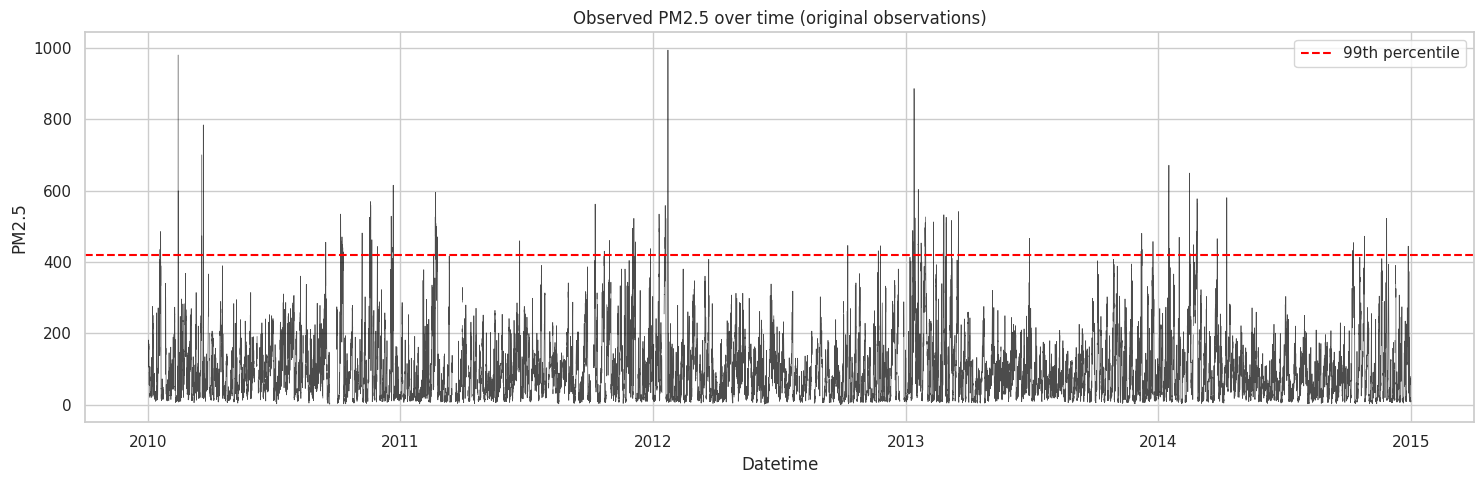

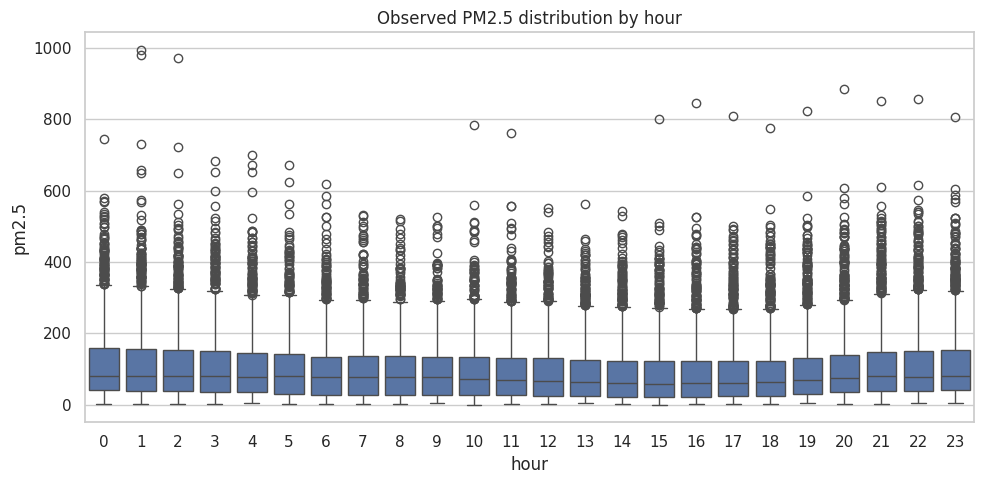

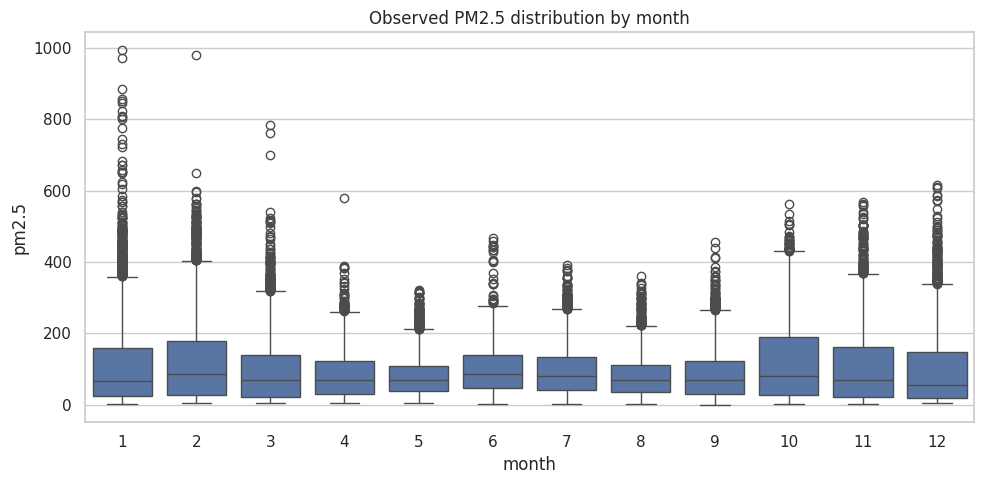

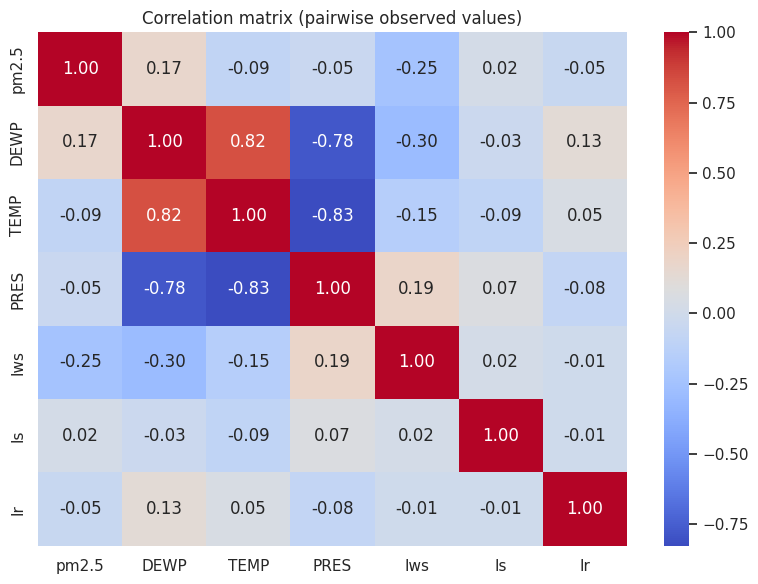

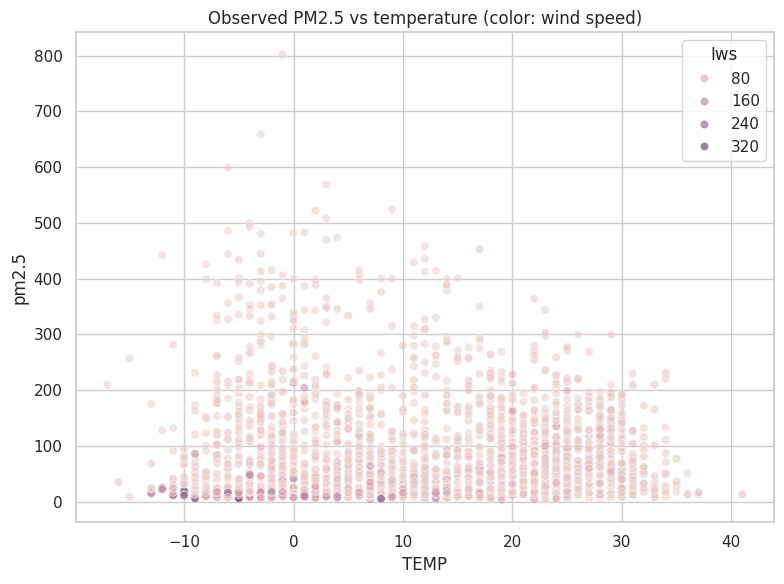

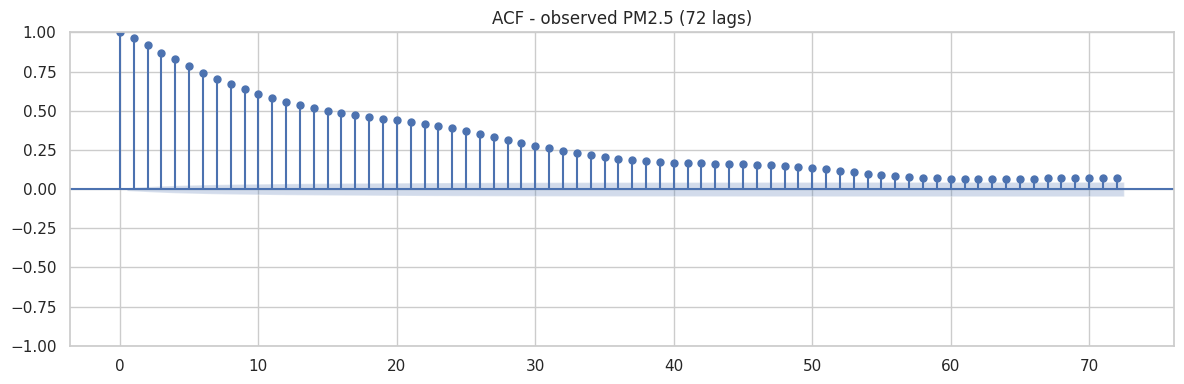

Đã lưu biểu đồ vào: /content/PPNCKH_5Bros/notebooks/phuong_nb/output/figures


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = load_raw_data()
df = df.loc[df["datetime"].notna()].sort_values("datetime").set_index("datetime")
if "pm2.5" not in df.columns:
    raise ValueError("Không tìm thấy cột pm2.5.")

sns.set_theme(style="whitegrid")

# 1. Time series: giá trị missing sẽ tạo khoảng trống trên đường biểu diễn.
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df["pm2.5"], color="black", linewidth=0.5, alpha=0.7)
if df["pm2.5"].notna().any():
    q99 = df["pm2.5"].quantile(0.99)
    ax.axhline(q99, color="red", linestyle="--", label="99th percentile")
    ax.legend()
ax.set_title("Observed PM2.5 over time (original observations)")
ax.set_xlabel("Datetime"); ax.set_ylabel("PM2.5")
fig.tight_layout()
fig.savefig(FIG_OUT / "EDA_1_TimeSeries.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# Thêm biến thời gian phục vụ các biểu đồ nhóm.
plot_df = df.copy()
plot_df["month"] = plot_df.index.month
plot_df["hour"] = plot_df.index.hour

# 2. Hourly distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x="hour", y="pm2.5", ax=ax)
ax.set_title("Observed PM2.5 distribution by hour")
fig.tight_layout()
fig.savefig(FIG_OUT / "EDA_2_Hourly.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# 3. Monthly distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x="month", y="pm2.5", ax=ax)
ax.set_title("Observed PM2.5 distribution by month")
fig.tight_layout()
fig.savefig(FIG_OUT / "EDA_3_Monthly.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# 4. Correlation among observed numeric variables
numeric_cols = [c for c in ["pm2.5", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"] if c in df.columns]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation matrix (pairwise observed values)")
fig.tight_layout()
fig.savefig(FIG_OUT / "EDA_4_Correlation.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# 5. Weather relationship; sample only for plotting.
if {"TEMP", "Iws", "pm2.5"}.issubset(df.columns):
    sample = df[["TEMP", "Iws", "pm2.5"]].dropna()
    if len(sample) > 2000:
        sample = sample.sample(2000, random_state=42)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=sample, x="TEMP", y="pm2.5", hue="Iws", alpha=0.6, ax=ax)
    ax.set_title("Observed PM2.5 vs temperature (color: wind speed)")
    fig.tight_layout()
    fig.savefig(FIG_OUT / "EDA_5_Weather.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# 6. ACF based on observed values in timestamp order; drop missing observations for ACF.
from statsmodels.graphics.tsaplots import plot_acf
observed_pm = df["pm2.5"].dropna()
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(observed_pm, lags=72, ax=ax, title="ACF - observed PM2.5 (72 lags)")
fig.tight_layout()
fig.savefig(FIG_OUT / "EDA_6_ACF.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Đã lưu biểu đồ vào:", FIG_OUT)